In [18]:
import pandas as pd
import re
import struct
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

from scipy.signal import find_peaks
from scipy.optimize import curve_fit

import matplotlib.colors as mcolors

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data 
import cigar as cig

from tqdm import tqdm


In [19]:


font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size
     


In [20]:
# colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue']
# Wong (2011) colorblind-safe palette – 8 distinct colors
# Works for deuteranopia, protanopia, and tritanopia

cute_colors = ['royalblue', 'crimson', 'green', 'darkorange', 'brown', 'blue', 'coral', 'indigo', 'magenta', 'black']

# Grayscale palette – 10 shades from near-black to light gray
# Paired with distinct markers and line styles for full grayscale legibility
GS_COLORS = [
    '#000000',  # Black
    '#1a1a1a',  # Near black
    '#333333',  # Very dark gray
    '#4d4d4d',  # Dark gray
    '#666666',  # Medium dark gray
    '#808080',  # Medium gray
    '#999999',  # Medium light gray
    '#b3b3b3',  # Light gray
    '#cccccc',  # Very light gray
    '#e6e6e6',  # Near white (use only on dark backgrounds)
]

CB_COLORS = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky blue
    '#009E73',  # Bluish green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish purple
    '#994F00',  # Brown        
    '#006CD1',  # Cerulean     
]

# Red-family palette – 10 perceptually distinct red-adjacent colors
# Ranges from deep maroon to coral/salmon, with warm and cool reds
RED_COLORS = [
    '#8B0000',  # Dark red / maroon
    '#CC0000',  # Pure strong red
    '#FF4500',  # Orange-red (OrangeRed)
    '#DC143C',  # Crimson (blue-toned red)
    '#B22222',  # Firebrick
    '#FF6347',  # Tomato (warm coral-red)
    '#C71585',  # Medium violet-red (pinkish)
    '#A0001C',  # Deep rose-red
    '#FF0066',  # Hot red-pink
    '#7B1010',  # Deep brick red
]

colors = cute_colors

# Distinct markers and line styles for extra redundancy (grayscale-safe)
CB_MARKERS    = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CB_LINESTYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']


##  Data reading

In [21]:
base        = f"/home/marian/CIGAR_ANALYSIS/CIGAR/data"
# run_base     = 'Run174SPheCH'   # prefix; per-channel run dirs: Run172SPheCH1, Run172SPheCH2, ...
# temperature  = 7
# pressure     = 7.5
run_base     = 'Run115SPheCH'   # prefix; per-channel run dirs: Run172SPheCH1, Run172SPheCH2, ...
temperature  = 14
pressure     = 1.5

In [22]:
# --- All 4 channels are processed together ---
all_channels = ['CH1', 'CH2', 'CH3', 'CH4']

nchannels       = 1 # per file
nevents_per_wvf = 2000

samples_per_waveform = 124
# samples_per_waveform = 752

event_header_bytes = 28
# event_header_bytes = 3036

# sample_binning = 1
sample_binning = 8e-9

nfiles = None
start  = 1


In [23]:
# Read data for all 4 channels and merge into a single DataFrame
# Each channel lives in its own run directory (Run172SPheCH1, ..., Run172SPheCH4).
# parse_data returns a column named 'CH1'; we rename it to the correct channel name.

channel_dfs = {}

for ch_idx, ch in enumerate(all_channels):
    channel_num = ch_idx + 1
    run         = f'{run_base}{channel_num}'
    run_dir     = f'{base}/{run}'

    dataframes = []
    for i, file in enumerate(tqdm(os.listdir(run_dir)[start:nfiles],
                                   desc=f'Reading {ch} .bin files', unit='file')):
        if file.endswith('.bin'):
            file_path = os.path.join(run_dir, file)
            df_tmp = parse_data.parse_wf_from_binary(
                file_path,
                channels=nchannels,
                n_events=nevents_per_wvf,
                file_idx=i,
                event_header_bytes=event_header_bytes
            )
            dataframes.append(df_tmp)

    ch_df = pd.concat(dataframes, ignore_index=True)
    ch_df.rename(columns={'CH1': ch}, inplace=True)   # parse_data always returns 'CH1'
    channel_dfs[ch] = ch_df

# Merge all channels on event + TIME (they share the same event structure)
df = channel_dfs['CH1'][['event', 'TIME', 'CH1']].copy()
for ch in ['CH2', 'CH3', 'CH4']:
    df = df.merge(channel_dfs[ch][['event', 'TIME', ch]], on=['event', 'TIME'], how='inner')

print(f'Merged DataFrame shape: {df.shape}')
df.tail()


Reading CH4 .bin files: 100%|██████████| 28/28 [00:11<00:00,  2.40file/s]


Merged DataFrame shape: (6944000, 6)


,event,TIME,CH1,CH2,CH3,CH4
6943995,55999,9.600000e-07,-646.989075,-623.232666,-602.074158,-600.292664
6943996,55999,9.680000e-07,-641.543945,-622.741699,-598.332703,-588.973328
6943997,55999,9.760000e-07,-639.830872,-619.611694,-597.105957,-590.511292
6943998,55999,9.840000e-07,-640.320374,-615.683899,-596.492615,-596.786133
6943999,55999,9.920000e-07,-640.932129,-614.640564,-594.161804,-597.831909


##  Data selection

In [24]:
event_list = df['event'].unique()
nevents    = len(event_list)
print(f'Total nevents = {nevents}')


Total nevents = 56000


###  Baseline

Same method as `ChargeSpectrum.ipynb`'s baseline-correction step (histogram the pretrigger samples, locate the peak with mode + local quadratic-in-log fit), computed from this run instead of the hardcoded values previously here. Everything below that reads `fixBaselines_Amp` (the CHARGE-vs-TIME plot, waveform density, both Finger Plots) picks this up automatically - check the fitted red curve visually tracks the histogram peak per channel.

In [25]:
def compute_baselines(df, nevents, pretrigger, run_base=None, plot=True):
    """
    Per-channel baseline offset from the pretrigger samples - same method
    as ChargeSpectrum.ipynb's "Baseline correction" step: histogram the
    first `pretrigger` samples of every waveform (no real signal should
    have arrived yet), then locate the peak by fitting a quadratic to
    log(counts + 1) in a small window around the tallest bin (equivalent
    to a local Gaussian fit, since the log of a Gaussian is a parabola,
    but more robust to noisy bins in the wings than fitting the raw counts
    directly). Falls back to the raw histogram mode if that fit fails.

    Returns a {'CH1': ..., 'CH2': ..., 'CH3': ..., 'CH4': ...} dict in the
    same format as the old hardcoded fixBaselines_Amp - assign the result
    back to that name to use it, since every cell below reads that global
    by name.
    """
    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(16, 10), dpi=150)
        title = f'Baseline (pretrigger={pretrigger})'
        if run_base:
            title += f' — {run_base}s'
        fig.suptitle(title)
        axs_flat = axs.flatten()

    fixBaselines_Amp = {}
    for i, channel in enumerate([1, 2, 3, 4]):
        ch = f'CH{channel}'

        voltage   = df[ch].values
        v_matrix  = voltage.reshape(nevents, -1)
        baselines = v_matrix[:, :pretrigger].flatten()

        counts, bins = np.histogram(baselines, bins=int(0.5 * np.sqrt(len(baselines))),
                                     range=(baselines.min(), 1000))
        bin_centers  = 0.5 * (bins[:-1] + bins[1:])
        mode_initial = bin_centers[np.argmax(counts)]

        bin_width = bins[1] - bins[0]
        window    = 0.05 * len(bins) * bin_width
        fit_mask  = (bin_centers >= mode_initial - window) & (bin_centers <= mode_initial + window)
        x_fit = bin_centers[fit_mask]
        y_fit = np.log(counts[fit_mask] + 1)

        coeffs = None
        try:
            coeffs = np.polyfit(x_fit, y_fit, 2)
            a, b, _ = coeffs
            peak_value = -b / (2 * a)
        except Exception:
            print(f'Baseline fit failed for {ch}, using histogram mode instead')
            peak_value = mode_initial

        fixBaselines_Amp[ch] = peak_value

        if plot:
            ax = axs_flat[i]
            ax.hist(baselines, bins=bins, color=colors[i], alpha=0.7, label=ch)
            if coeffs is not None:
                x_fine = np.linspace(x_fit.min(), x_fit.max(), 200)
                ax.plot(x_fine, np.exp(np.polyval(coeffs, x_fine)) - 1, '-r', lw=2, label='Quadratic fit')
            ax.axvline(peak_value, color='red', linestyle='--', lw=2, label=f'{peak_value:.1f} mV')
            ax.set_xlabel('Baseline [mV]')
            ax.set_ylabel('Counts')
            ax.set_yscale('log')
            ax.grid(True)
            ax.legend(fontsize=font_size * 0.7)

    if plot:
        plt.tight_layout()
        plt.show()

    return fixBaselines_Amp

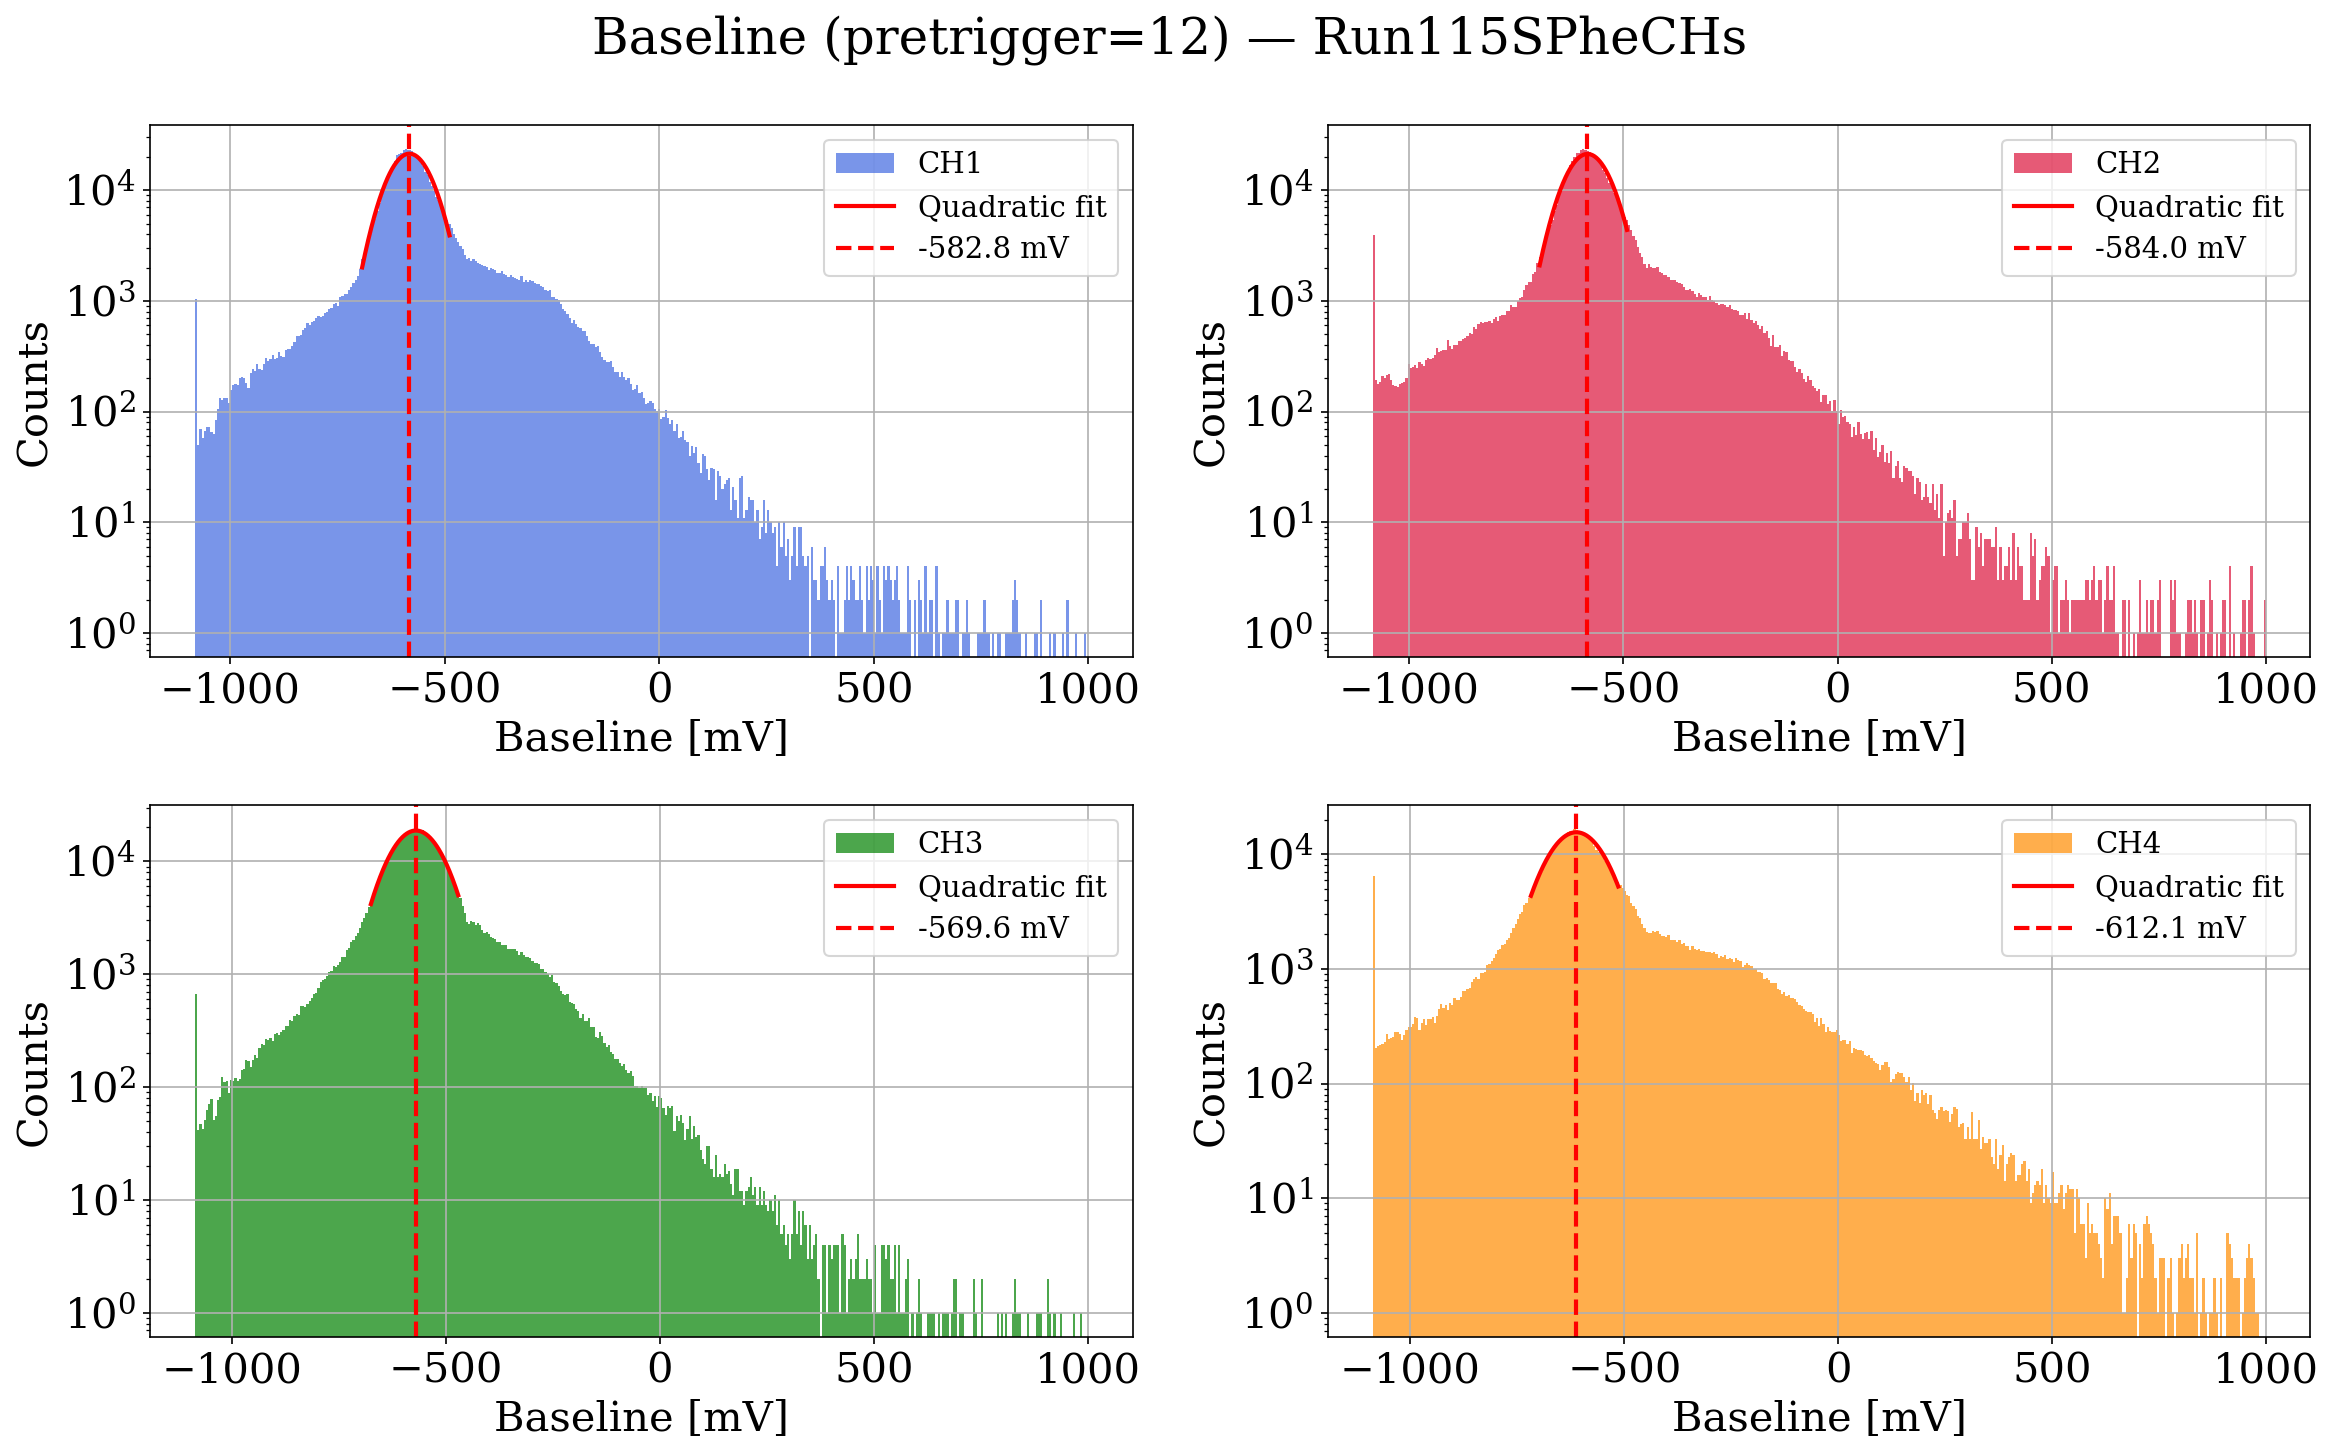

fixBaselines_Amp: {'CH1': -582.7756390771194, 'CH2': -584.025865615167, 'CH3': -569.6207613915634, 'CH4': -612.1048529932315}


In [26]:
pretrigger = 12   # pretrigger samples used as the baseline region - waveform is only 124 samples long

fixBaselines_Amp = compute_baselines(df, nevents, pretrigger, run_base)
print('fixBaselines_Amp:', fixBaselines_Amp)

In [27]:
channels = all_channels   # ['CH1', 'CH2', 'CH3', 'CH4']

selected_event = 202


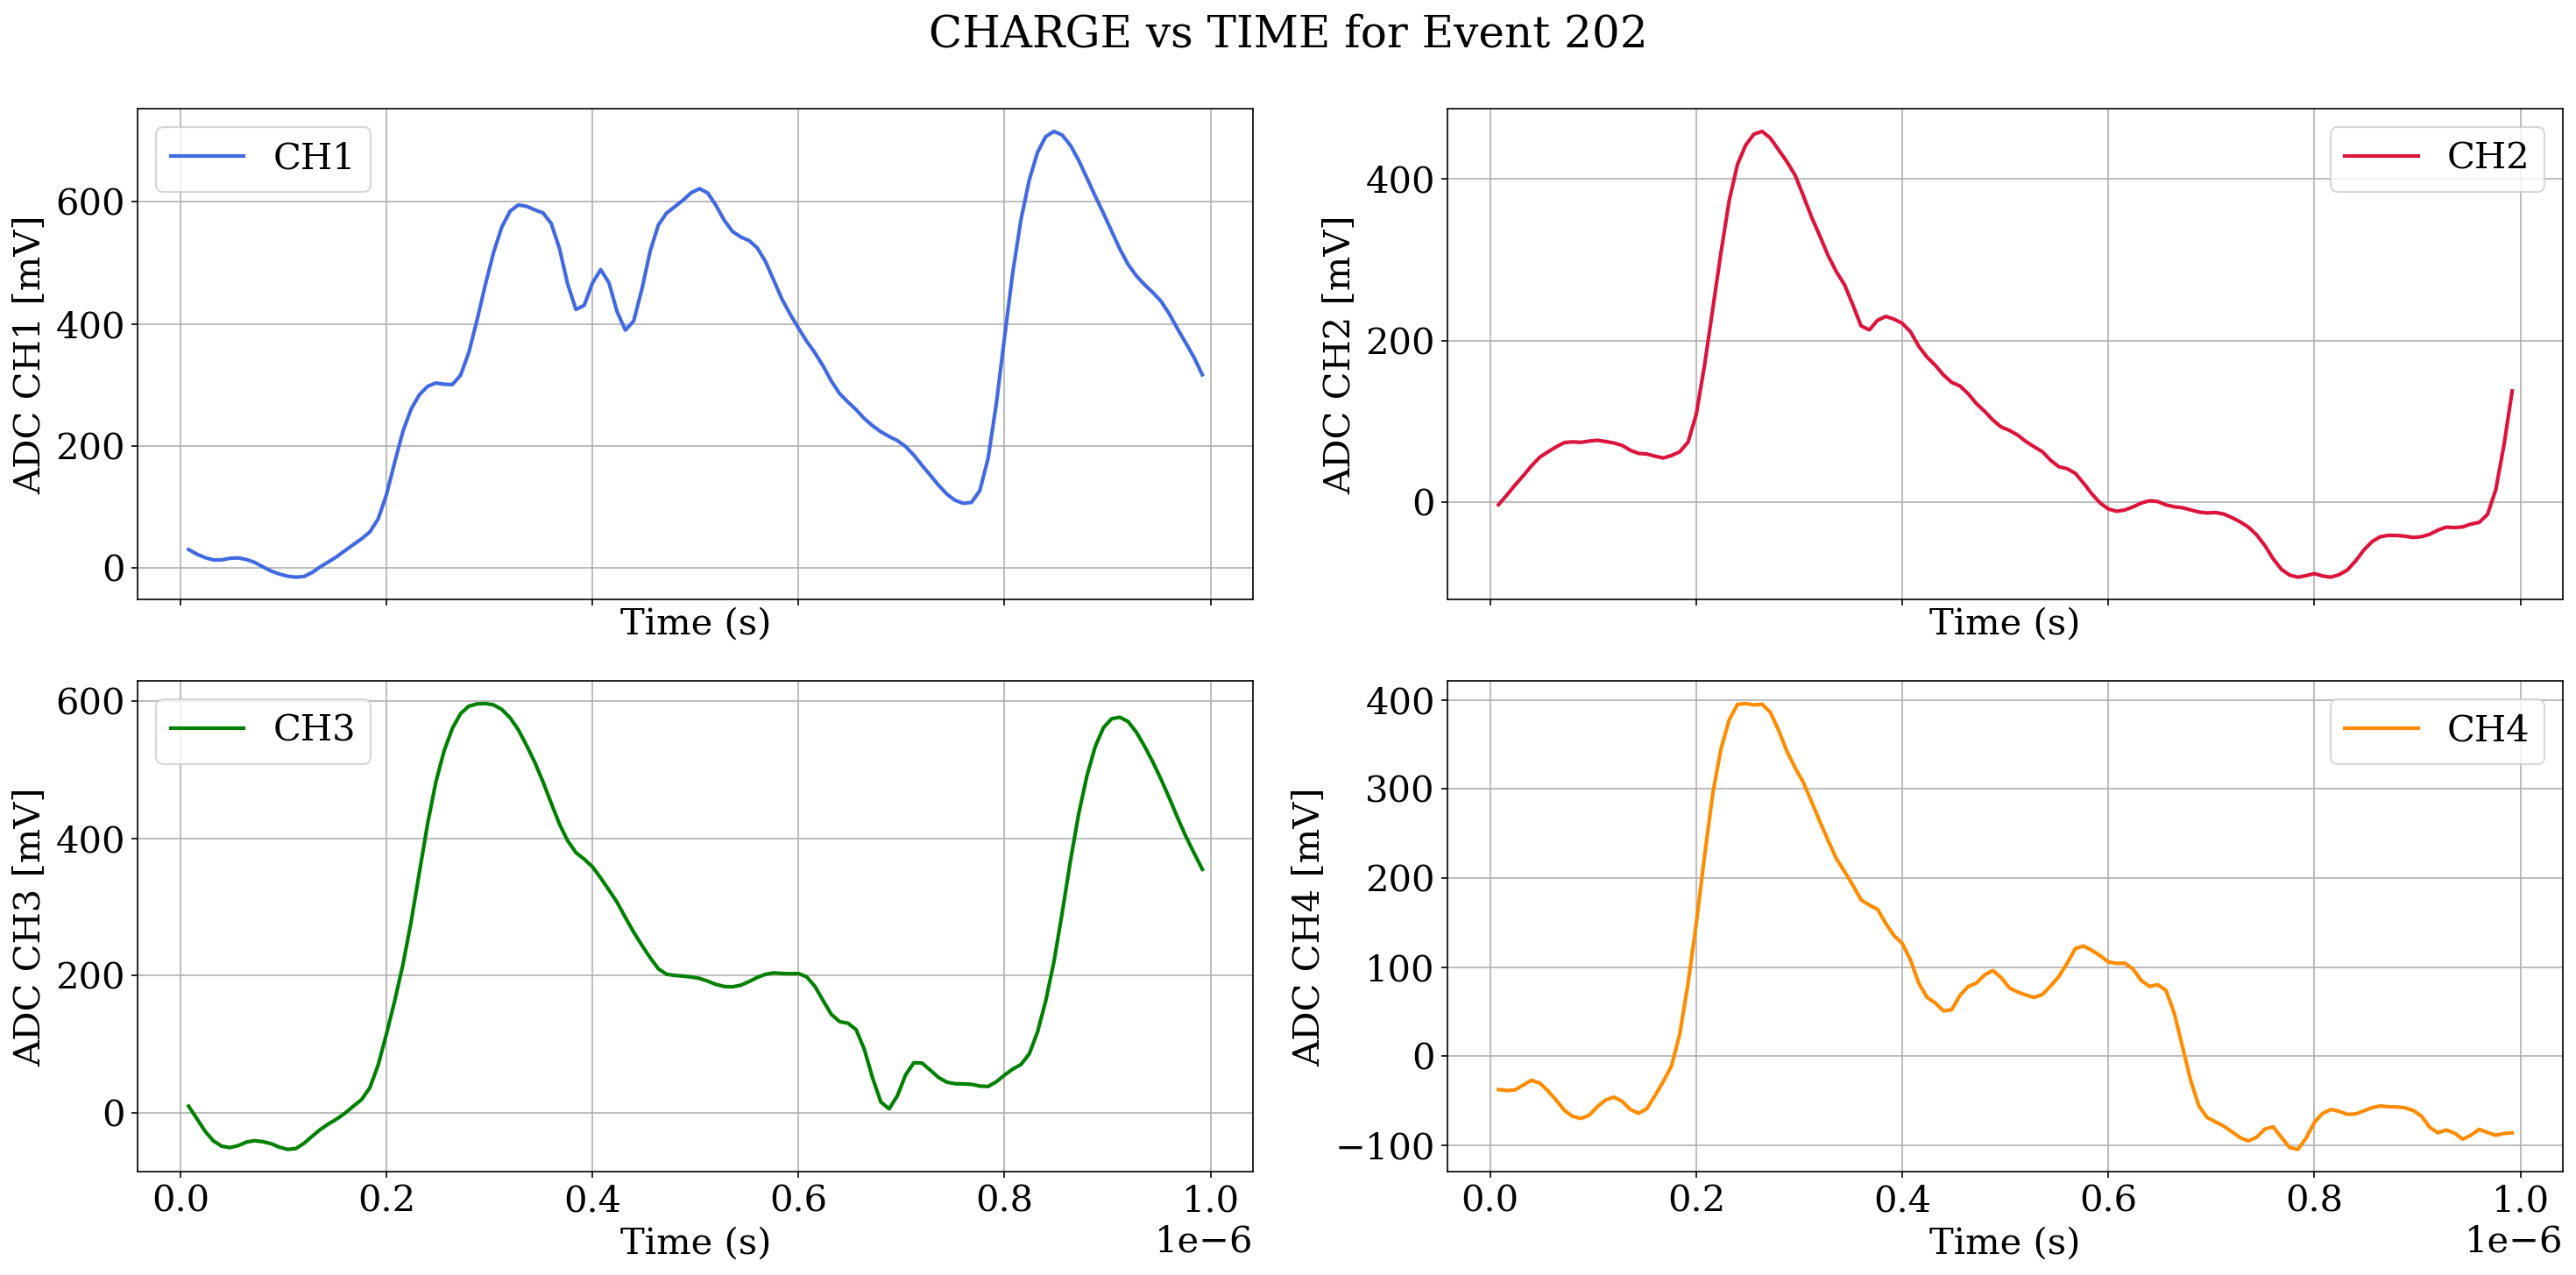

In [30]:
df_event = df[df['event'] == event_list[selected_event]]


fig, axs = plt.subplots(2, 2, figsize=(20, 10), dpi=150, sharex=True, sharey=False)
fig.suptitle(f'CHARGE vs TIME for Event {event_list[selected_event]}')
axs_flat = axs.flatten()

for i, ch in enumerate(channels):
    ax = axs_flat[i]
    df_event_corrected = df_event - fixBaselines_Amp[ch]
    ax.plot(df_event['TIME'].values, df_event_corrected[ch].values,
            marker='', linestyle='-', color=colors[i], markersize=3, linewidth=2, label=ch)
    ax.set_ylabel(f'ADC {ch} [mV]')
    ax.set_xlabel('Time (s)')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


##  Data filtering

In [31]:
# Remove events with more than 4 peaks above threshold across all channels
def count_high_peaks(group, threshold=2000):
    peak_count = 0
    for ch in channels:
        peaks, _ = find_peaks(group[ch].values, height=threshold)
        peak_count += len(peaks)
    return peak_count

peak_counts  = df.groupby('event').apply(count_high_peaks)
valid_events = peak_counts[peak_counts <= 4].index

filtered_df = df[df['event'].isin(valid_events)]

event_list = filtered_df['event'].unique()
nevents    = len(event_list)
print(f'Events after filtering: {nevents}')


/tmp/ipykernel_7182/3951954891.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  peak_counts  = df.groupby('event').apply(count_high_peaks)


Events after filtering: 56000


##  Integration window

In [32]:
window_width = 20

t_matrix = filtered_df['TIME'].values.reshape(nevents, -1)
time     = t_matrix[0]


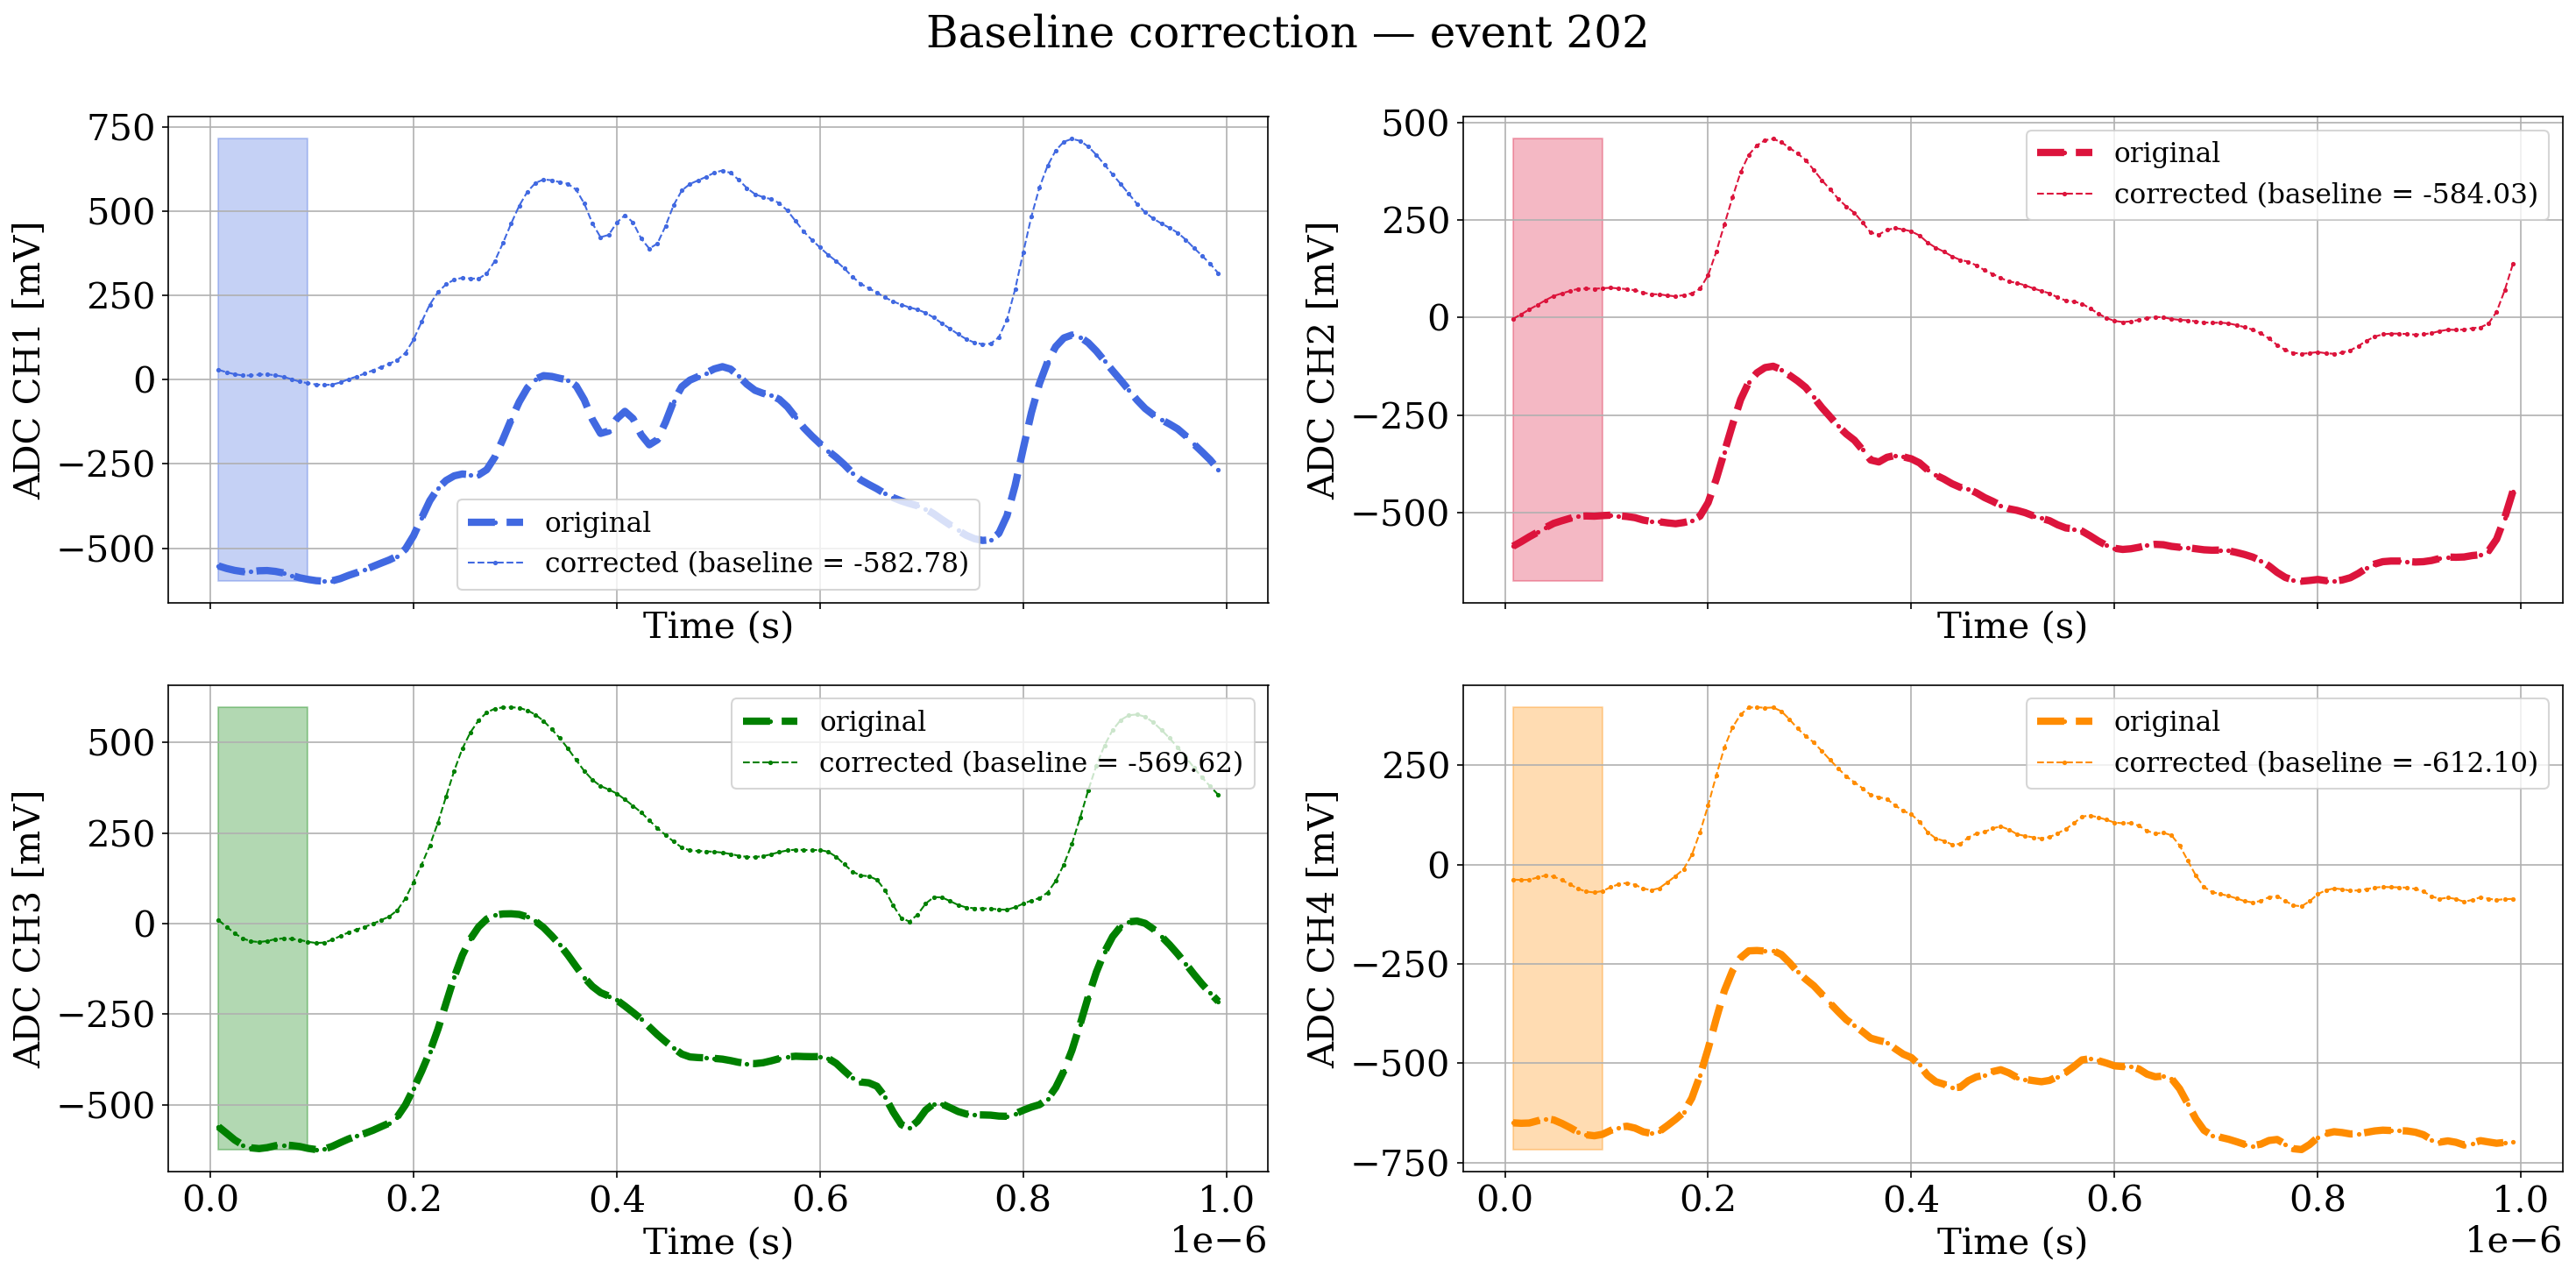

In [55]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10), dpi=150, sharex=True, sharey=False)
fig.suptitle(f'Baseline correction — event {event_list[selected_event]}')
axs_flat = axs.flatten()

for i, ch in enumerate(channels):
    ax = axs_flat[i]
    voltage    = filtered_df[ch].values
    v_matrix   = voltage.reshape(nevents, -1)
#     v_matrix_corrected, baselines, window = cig.BaselineCorrection(v_matrix, window=window_width)
    v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]
    window = pretrigger

    ax.plot(t_matrix[selected_event], v_matrix[selected_event],
            marker='.', linestyle='--', color=colors[i], markersize=3, linewidth=4, label='original')
    ax.plot(t_matrix[selected_event], v_matrix_corrected[selected_event],
            marker='.', linestyle='--', color=colors[i], markersize=3, linewidth=1,
            label=f'corrected (baseline = {fixBaselines_Amp[ch]:.2f})')

    ax.fill_between(time[:pretrigger],
                    v_matrix[selected_event].min(),
                    v_matrix_corrected[selected_event].max(),
                    color=colors[i], alpha=0.3)

    ax.set_ylabel(f'ADC {ch} [mV]')
    ax.set_xlabel('Time (s)')
    ax.grid(True)
    ax.legend(fontsize=15)

plt.tight_layout()
plt.show()


In [34]:
# time_window = (0.18e-6 < time) & (time <= 0.45e-6)
time_window = (0.18e-6 < time) & (time <= 0.6e-6)
# time_window = (0.18e-6 < time) & (time <= 0.8e-6)
# time_window = (0.18e-6 < time) & (time <= 0.7e-6)


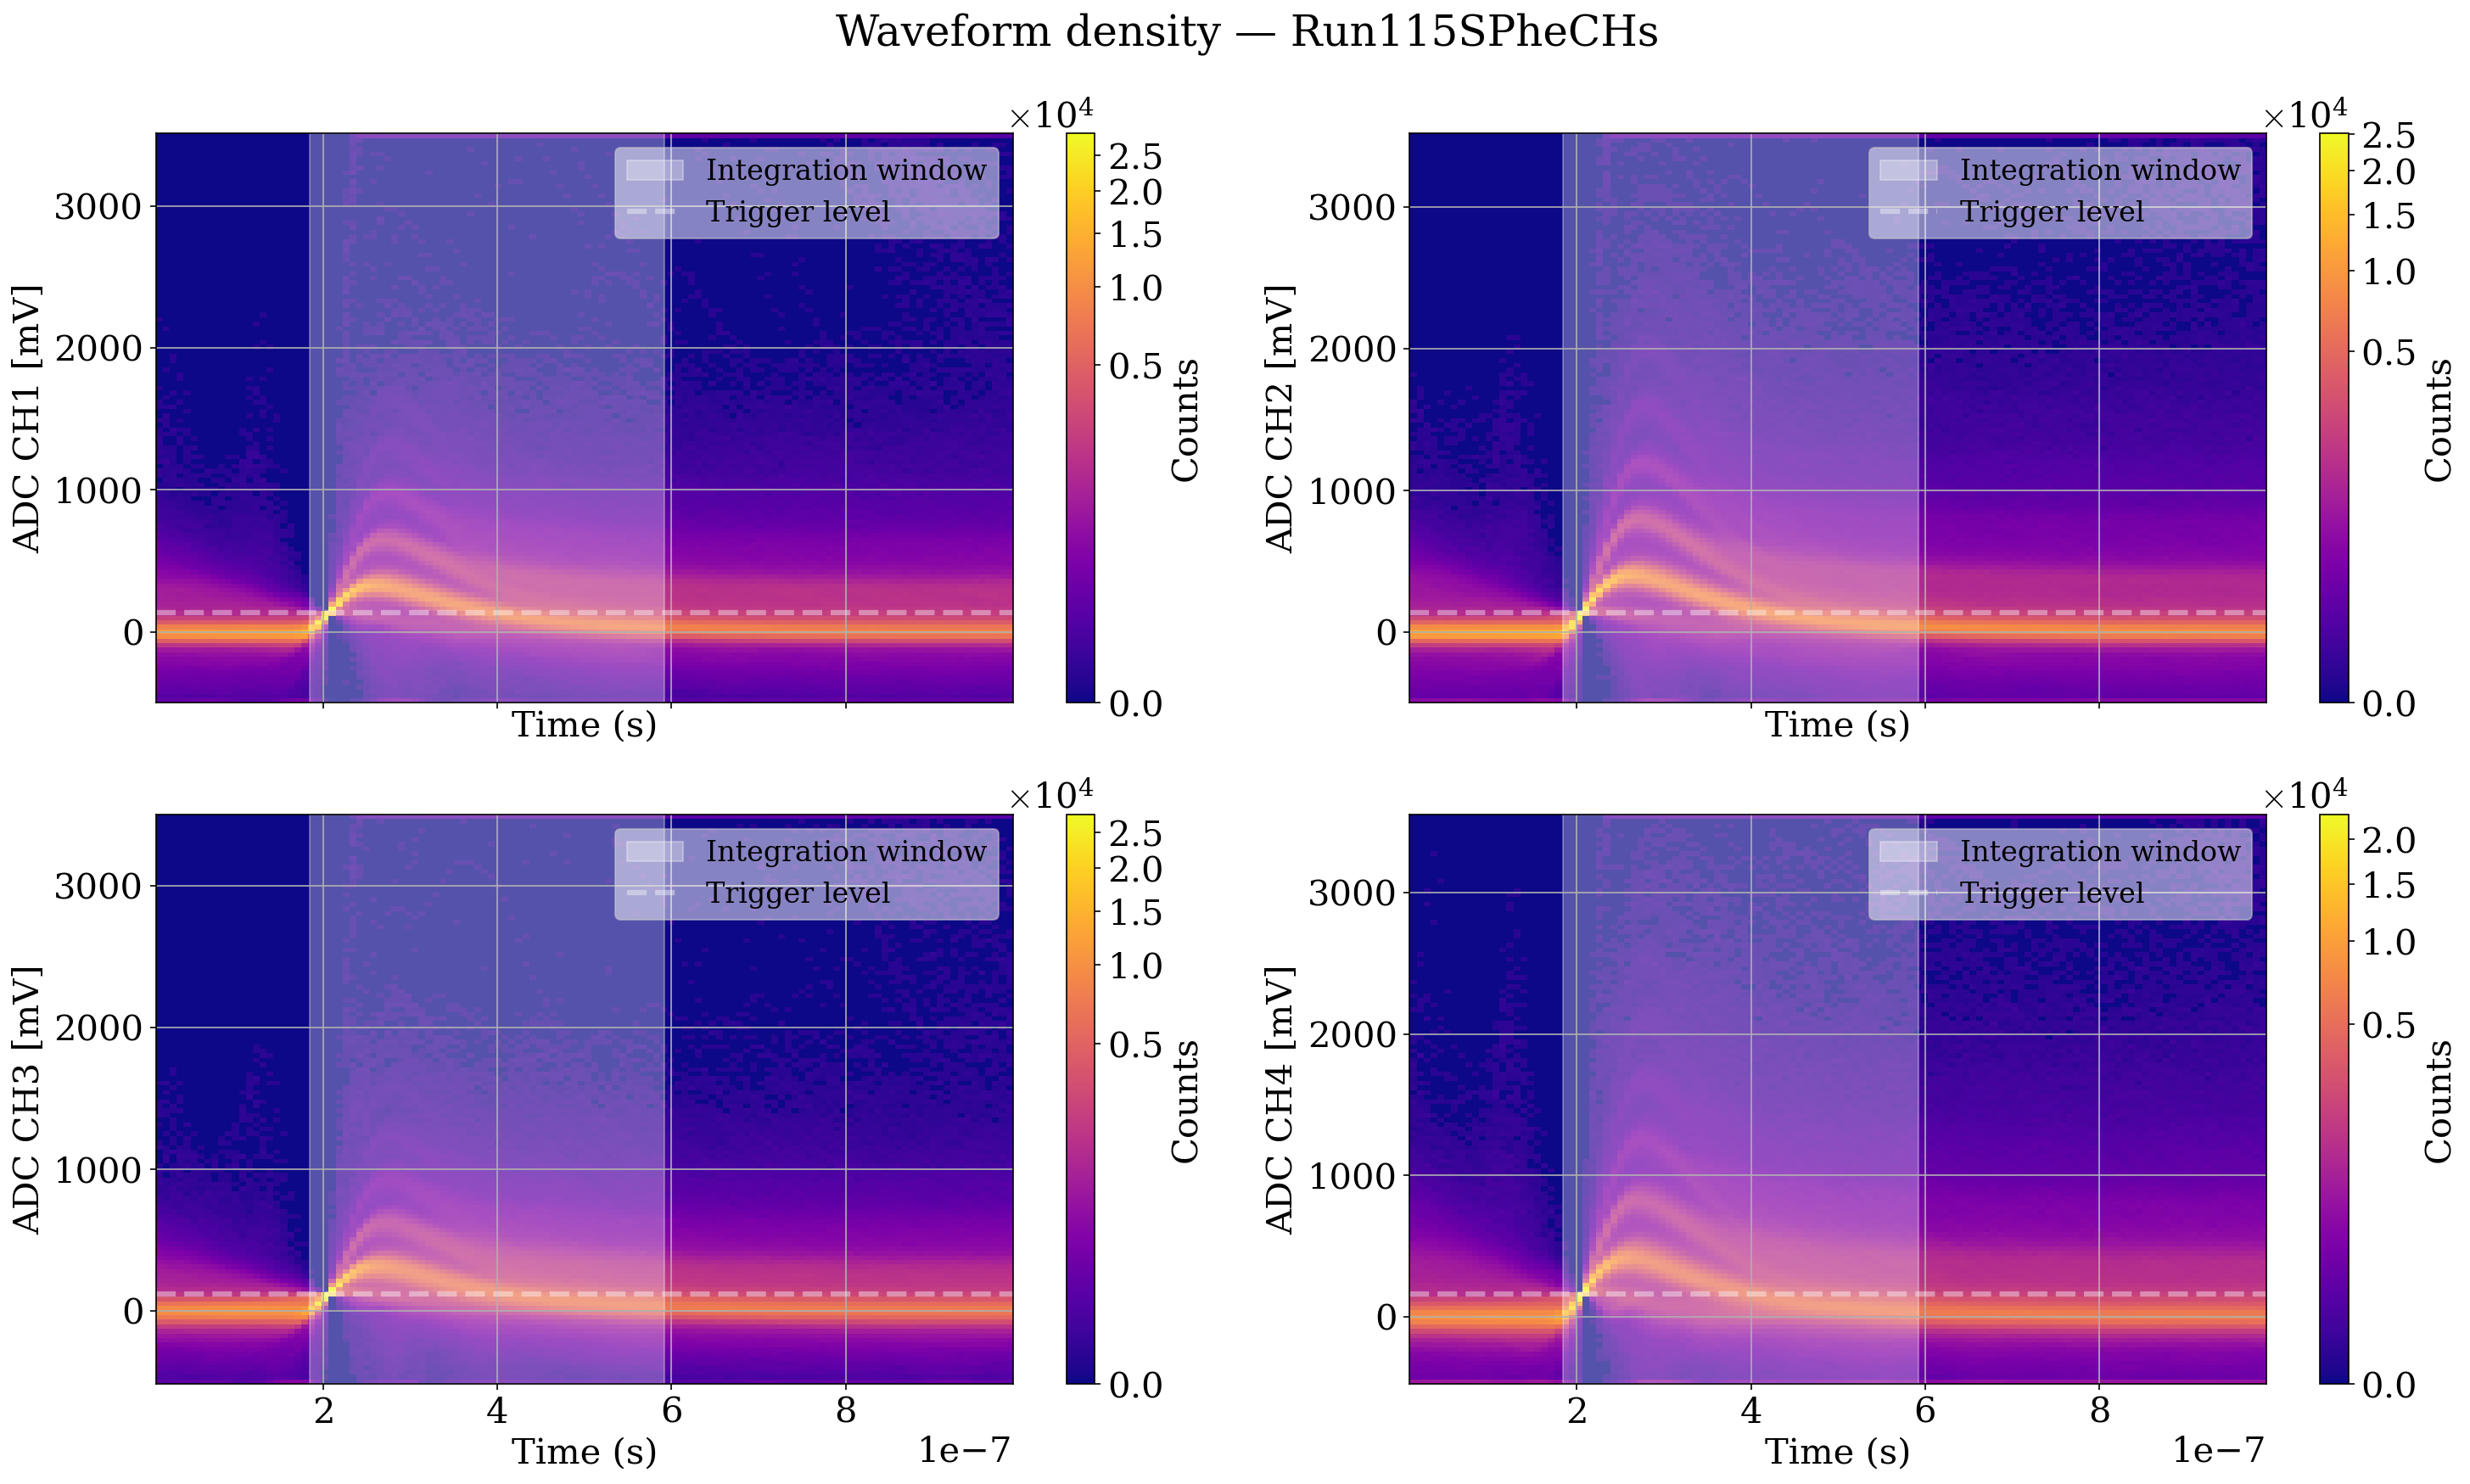

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(20, 12), dpi=150, sharex=True, sharey=False)
fig.suptitle(f'Waveform density — {run_base}s')
axs_flat = axs.flatten()

for i, ch in enumerate(channels):
    ax = axs_flat[i]
    voltage            = filtered_df[ch].values
    v_matrix           = voltage.reshape(nevents, -1)
    v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]
    # v_matrix_corrected, baselines, window = cig.BaselineCorrection(v_matrix, window=window_width)


    hb = ax.hist2d(t_matrix.flatten(), v_matrix_corrected.flatten(),
                   bins=[np.shape(t_matrix)[1], np.shape(v_matrix_corrected)[1]],
                   cmap='plasma', norm=mcolors.PowerNorm(gamma=0.3))
    cbar = fig.colorbar(hb[3], ax=ax, label='Counts')
    cbar.formatter.set_powerlimits((0,0))
    cbar.formatter.set_useMathText(True)


    ax.fill_between(time[time_window],
                    v_matrix_corrected.min(), v_matrix_corrected.max(),
                    color='white', alpha=0.3, label='Integration window')
    
    ax.axhline(-fixBaselines_Amp[ch] - 450, color='white', alpha = 0.4, linestyle='--', lw=3, label='Trigger level')


    ax.set_ylabel(f'ADC {ch} [mV]')
    ax.set_xlabel('Time (s)')
    ax.grid(True)
    # ax.set_ylim(0, 700)
    ax.legend(framealpha=0.5, fontsize=font_size*0.8)

plt.tight_layout()
plt.show()


In [36]:
save = False
if save:
    mean_waveforms = {}
    for i, ch in enumerate(channels):
        voltage              = filtered_df[ch].values
        v_matrix             = voltage.reshape(nevents, -1)
        # v_matrix_corrected   = v_matrix - fixBaselines_Amp[ch]
        v_matrix_corrected, baselines, window = cig.BaselineCorrection(v_matrix, window=window_width)

        # keep only events whose maximum sample exceeds threshold
        threshold      = 300   # [mV]
        mask           = v_matrix_corrected.max(axis=1) > threshold
        n_above        = mask.sum()
        print(f'{ch}: {n_above}/{nevents} events with peak > {threshold} mV')

        mean_waveforms[ch] = np.mean(v_matrix_corrected[mask], axis=0)

        run = f'{run_base}{i+1}'
        np.savez(f'{base}/mean_waveforms/mean_waveforms_{run}.npz',
                 **{f'ch_{ch}': mean_waveforms[ch]},
                 time          = time,
                 channels      = np.array([ch]),
                 time_window   = time_window,
                 threshold     = threshold,
                 n_events_used = n_above)
        print(f'Saved mean waveforms to mean_waveforms_{run}.npz')

In [37]:
run_base

'Run115SPheCH'

In [38]:
channels

['CH1', 'CH2', 'CH3', 'CH4']

# CHARGE

##  Finger Plot

In [39]:
def FingerPlot(df, channels, n_gaussians_list, test = False):
    """Charge finger plot for all channels in a 2x2 grid."""

    opt_A, opt_mu, opt_sigma, opt_mu_errors = {}, {}, {}, {}
    fig, axs = plt.subplots(2, 2, figsize=(20, 16), dpi=150)
    fig.suptitle(f'{run_base}s — Charge Finger Plot')
    axs_flat = axs.flatten()

    for i, ch in enumerate(channels):
        ax = axs_flat[i]
        voltage            = df[ch].values
        v_matrix           = voltage.reshape(nevents, -1)
        v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]
        # v_matrix_corrected, _, _ = cig.BaselineCorrection(v_matrix, window=window_width)

        n_gaussians = n_gaussians_list[i]
        charge = np.trapz(v_matrix_corrected[:, time_window],
                          x=time[time_window], axis=1)
        if i < 2:
            # hist_range = (0, 3.e-4)
            hist_range = (0, 3.e-4)
        if i == 1:
            hist_range = (0, 3.e-4)
        else:
            # hist_range = (-1e-5, 2.1e-4)
            hist_range = (0.5e-4, 3e-4)
            # hist_range = (0.5e-4, 3.5e-4)

        if test:
            hist_range = None
        

        events_hist, bins, _ = ax.hist(charge,
                                       bins=int(np.sqrt(len(charge))),
                                       range=hist_range,
                                       density=False,
                                       color=colors[i],
                                       alpha=0.3,
                                       label=ch)
        
        bins_means = (bins[:-1] + bins[1:]) / 2
        peak_distance = 40 if i < 2 else 60
        # peak_distance = 15 if i < 2 else 20
        peaks, _ = find_peaks(events_hist, distance=peak_distance, prominence=0.6)
        ax.plot(bins_means[peaks], events_hist[peaks], 'or', markersize=20, alpha=0.3)

        msk = ((bins_means > (bins_means[events_hist.argmax()] + bins_means[0]) * 0.05) &
               (bins_means < bins_means[peaks[n_gaussians - 1]] * 1.15))
        x = bins_means[msk]
        y = events_hist[msk]
        initial_guess_A     = list(events_hist[peaks][:n_gaussians])
        initial_guess_mu    = list(bins_means[peaks][:n_gaussians])
        initial_guess_sigma = [0.6 * (bins_means[1] - bins_means[0])] * n_gaussians
        initial_guess       = initial_guess_A + initial_guess_mu + initial_guess_sigma
        params, covariance = curve_fit(cig.sum_of_gaussians, x, y, p0=initial_guess, maxfev=100000)
        for j in range(10):
            lower  = np.minimum(params * 0.8, params * 1.2)
            upper  = np.maximum(params * 0.8, params * 1.2)
            bounds = (lower, upper)
            params, covariance = curve_fit(cig.sum_of_gaussians, x, y,
                                           p0=params, bounds=bounds, maxfev=100000)
        opt_A[ch]         = params[:n_gaussians]
        opt_mu[ch]        = params[n_gaussians:2*n_gaussians]
        opt_sigma[ch]     = params[2*n_gaussians:]
        opt_mu_errors[ch] = np.sqrt(np.diag(covariance)[n_gaussians:2*n_gaussians])
        gaussian_sum = cig.sum_of_gaussians(x, *params)
        ax.plot(x, gaussian_sum, color=colors[i], lw=3, alpha=1, label='Gaussian Fit')

        for jj, mu in enumerate(opt_mu[ch]):
            y_marker = cig.sum_of_gaussians(mu, *params)
            one_g    = [opt_A[ch][jj], opt_mu[ch][jj], opt_sigma[ch][jj]]
            ax.plot(mu, y_marker, 'X', color='k', markersize=10, zorder=5)  # no label
            ax.plot(x, cig.sum_of_gaussians(x, *one_g), '--', color='k')
            ax.annotate(fr'$\mu_{{{jj+1}}}$={mu:.2E}',         # <-- text above marker
                        xy=(mu, y_marker),
                        xytext=(0, 12), 
                        textcoords='offset points',
                        ha='center', 
                        va='bottom', 
                        fontsize=font_size*0.8,
                        color='k'
                        )

        ax.xaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useMathText=True))  # <-- sci notation
        ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

        ax.set_title(ch)
        ax.set_xlabel(r'Charge [mV·s]')
        ax.set_ylabel('Counts')
        ax.grid(True)
        ax.legend(fontsize=font_size)

    plt.tight_layout()
    plt.show()
    return opt_A, opt_mu, opt_sigma, opt_mu_errors

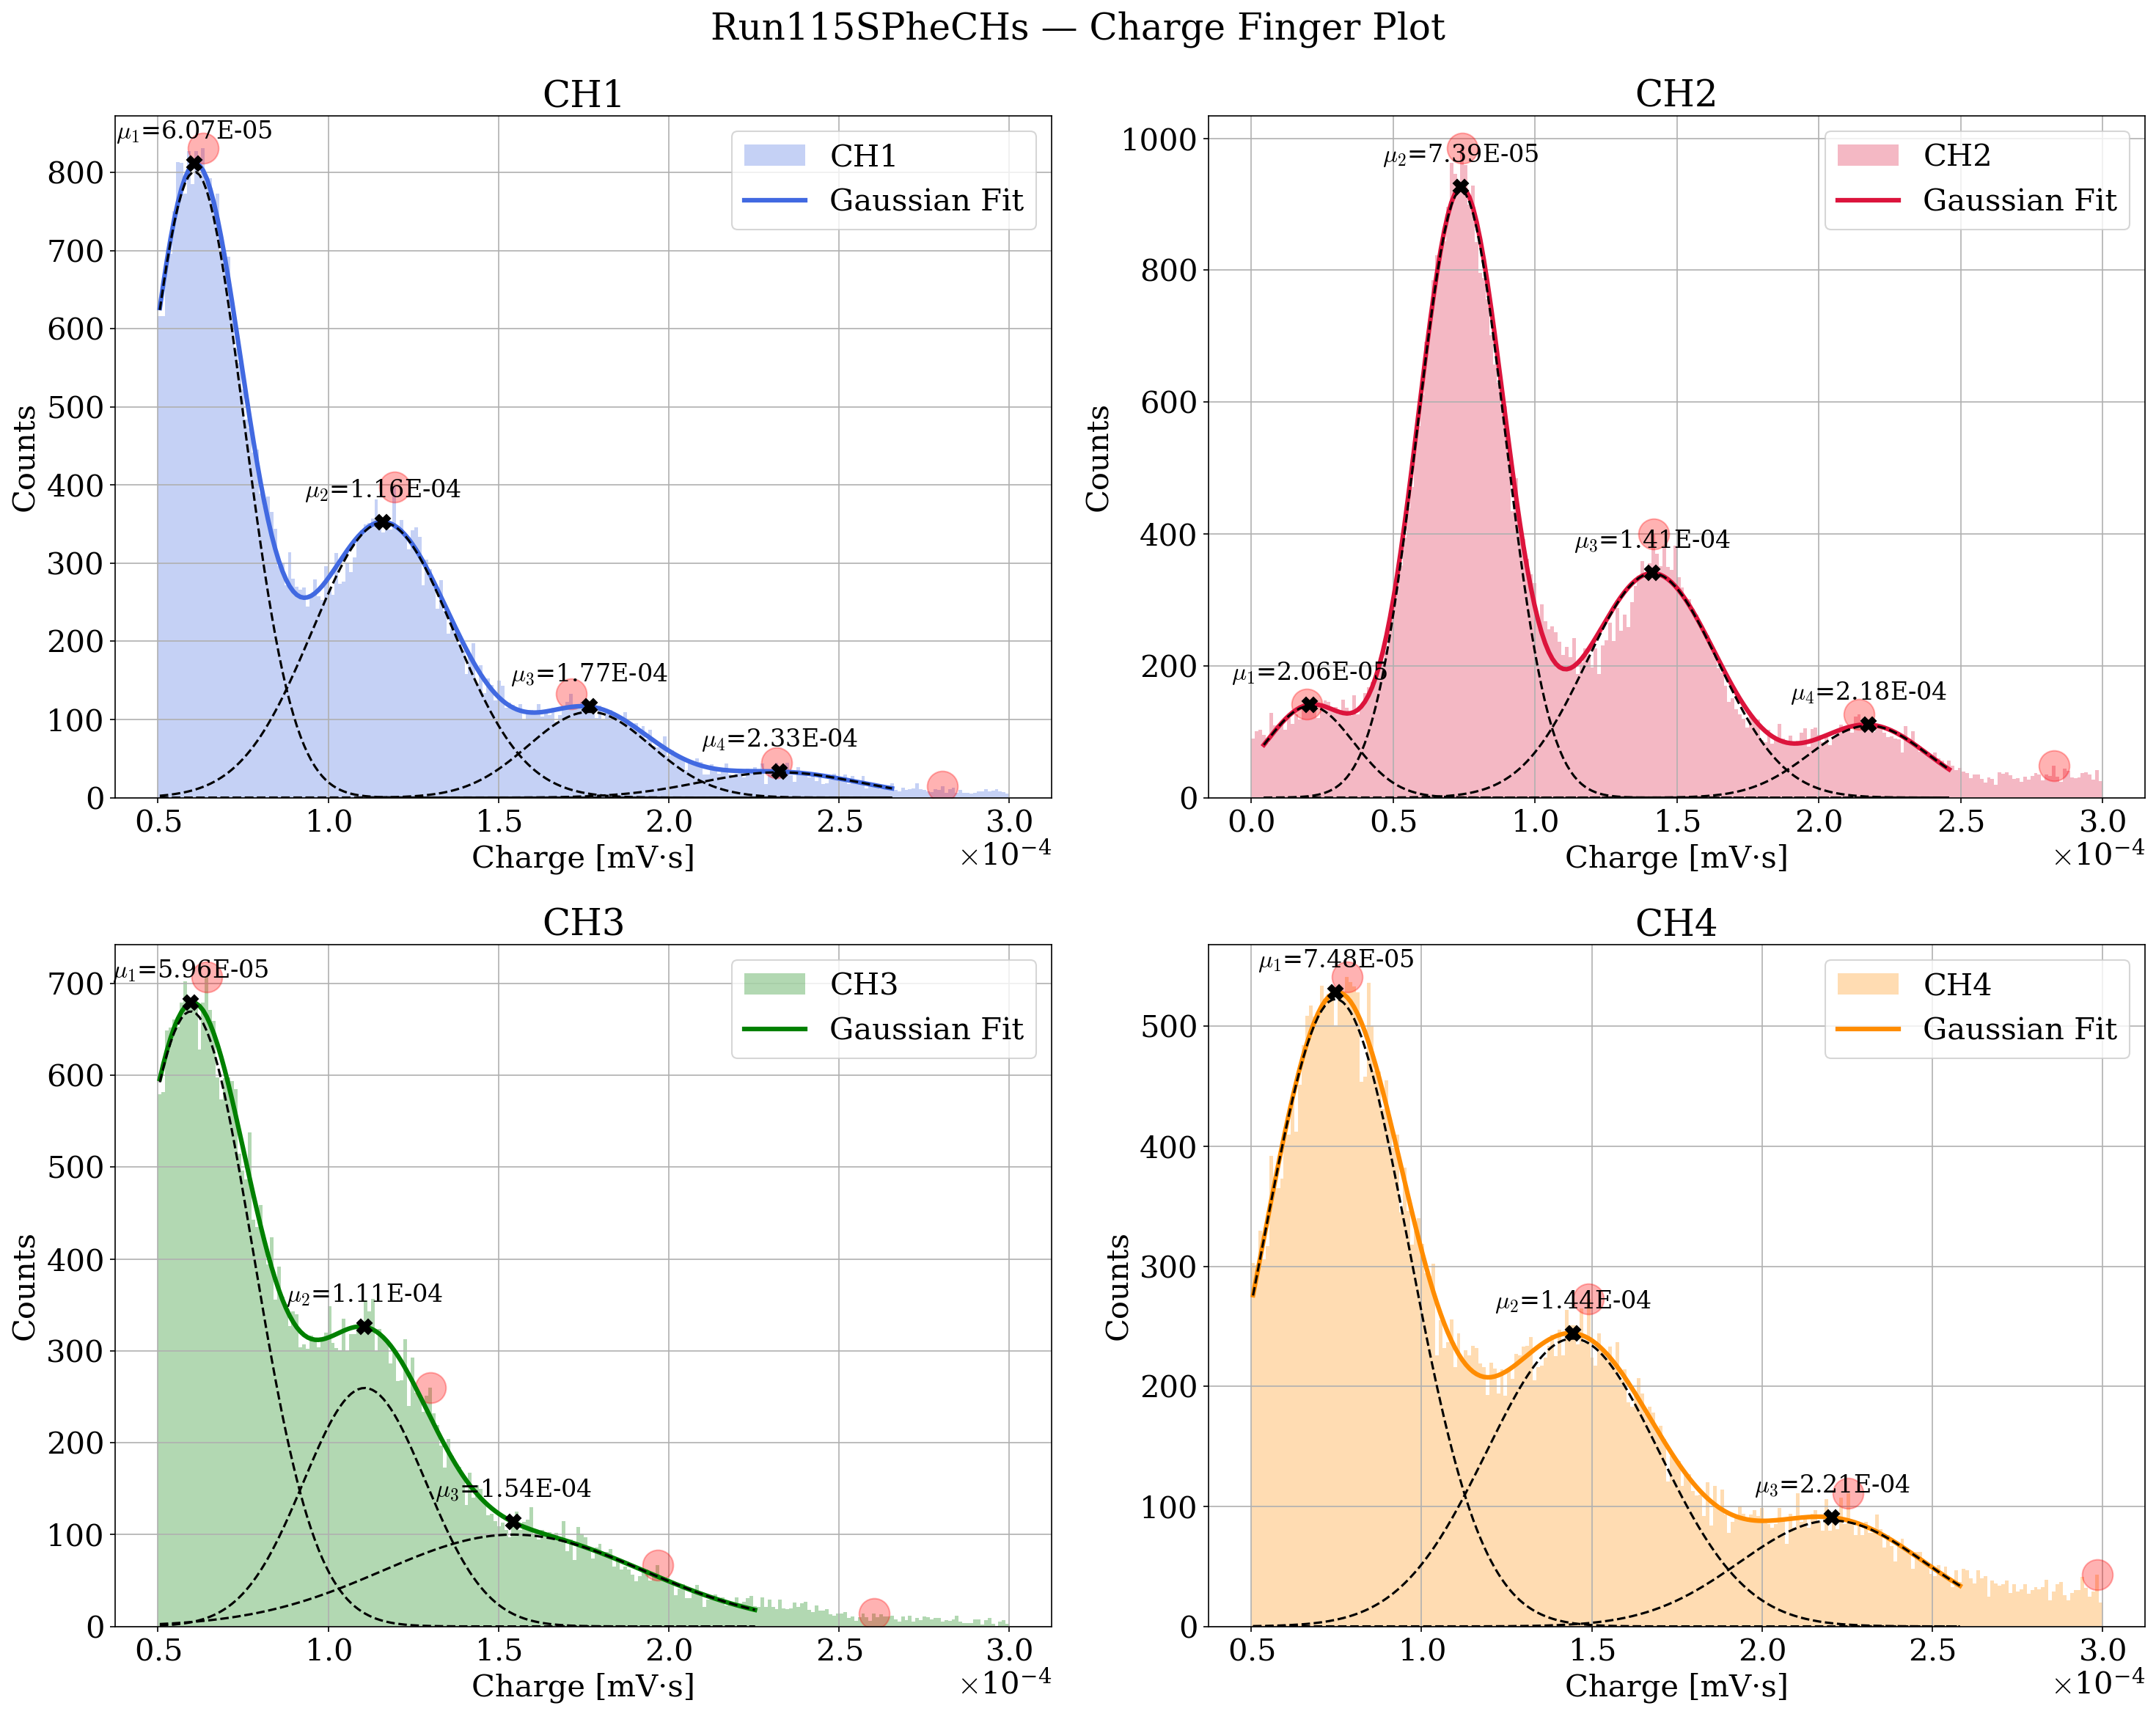

In [47]:
n_gaussians = [4, 4, 3, 3]
opt_A, opt_mu, opt_sigma, opt_mu_errors = FingerPlot(filtered_df, channels, n_gaussians, test=False)


##  Data Analysis: Linearity

In [48]:
opt_mu


{'CH1': array([6.07263981e-05, 1.16046474e-04, 1.76747849e-04, 2.32506551e-04]),
 'CH2': array([2.06302681e-05, 7.39202529e-05, 1.41389405e-04, 2.17601517e-04]),
 'CH3': array([5.96346813e-05, 1.10693776e-04, 1.54314731e-04]),
 'CH4': array([7.47972729e-05, 1.44459075e-04, 2.20583652e-04])}

In [49]:
pes_spectrum = opt_mu
err_spectrum = opt_mu_errors


In [50]:
# npeaks = -1  # all except last one
npeaks = None   # all


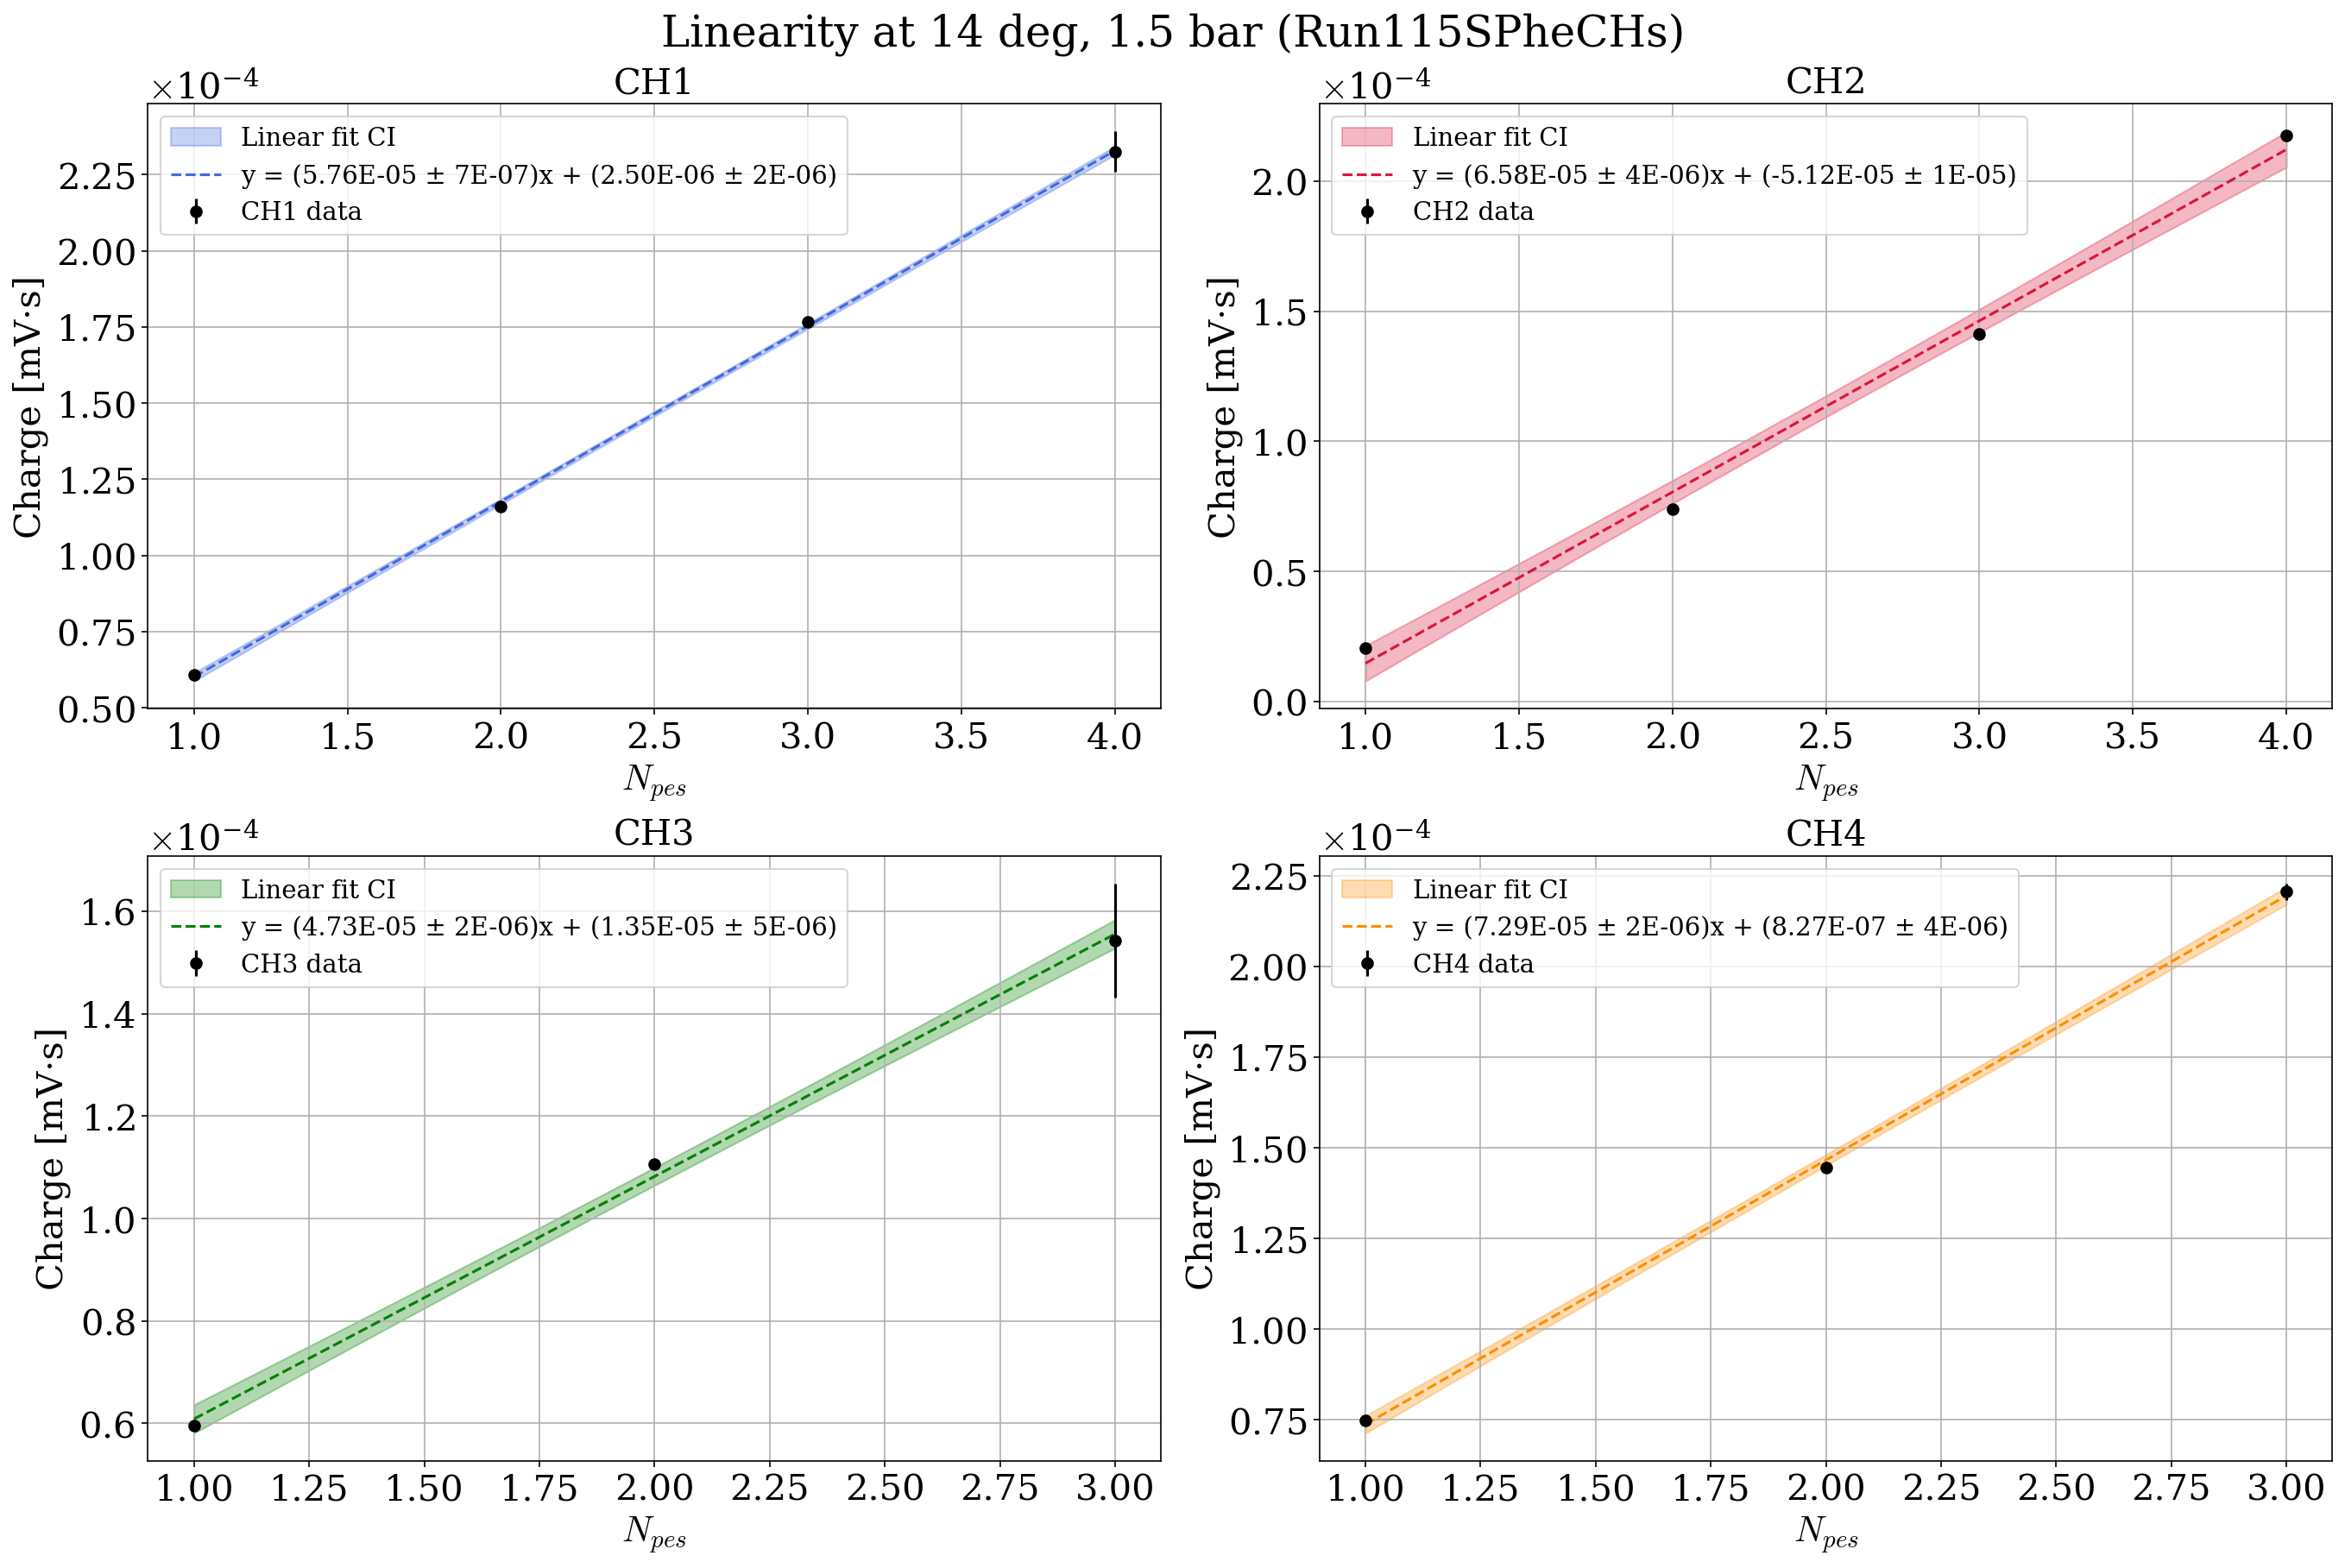

In [51]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12), dpi=150, constrained_layout=True)
fig.suptitle(f'Linearity at {temperature} deg, {pressure} bar ({run_base}s)')
axs_flat = axs.flatten()

for idx, ch in enumerate(pes_spectrum.keys()):
    ax = axs_flat[idx]

    x = np.arange(len(pes_spectrum[ch][:npeaks])) + 1
    y = pes_spectrum[ch][:npeaks]
    order = np.argsort(y)
    y = y[order]

    params, cov = np.polyfit(x, y, 1, cov=True)
    slope, intercept = params
    slope_err     = np.sqrt(cov[0, 0])
    intercept_err = np.sqrt(cov[1, 1])

    x_fit     = np.linspace(min(x), max(x), 200)
    y_fit     = slope * x_fit + intercept
    y_fit_var = (x_fit**2) * cov[0,0] + cov[1,1] + 2 * x_fit * cov[0,1]
    y_fit_err = np.sqrt(y_fit_var)

    ax.errorbar(x, y, yerr=err_spectrum[ch][:npeaks][order],
                fmt='o', alpha=1, color='k', label=f'{ch} data')
    ax.fill_between(x_fit, y_fit - y_fit_err, y_fit + y_fit_err,
                    color=colors[idx], alpha=0.3, label='Linear fit CI')
    ax.plot(x_fit, y_fit, color=colors[idx], linestyle='--',
            label=f'y = ({slope:.2E} ± {slope_err:.0E})x + ({intercept:.2E} ± {intercept_err:.0E})')


    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useMathText=True))  # <-- sci notation
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    
    ax.set_title(ch, fontsize=font_size)
    ax.set_xlabel(r'$N_{pes}$', fontsize=font_size)
    ax.set_ylabel(r'Charge [mV·s]', fontsize=font_size)
    ax.grid(True)
    ax.legend(fontsize=font_size*0.7, loc='upper left')

plt.show()


# PEAK VOLTAGE

##  Finger Plot

In [45]:
def FingerPlotVoltage(df, channels, n_gaussians):
    """Peak-voltage finger plot for all channels in a 2x2 grid."""

    opt_A, opt_mu, opt_sigma, opt_mu_errors = {}, {}, {}, {}

    fig, axs = plt.subplots(2, 2, figsize=(20, 16), dpi=150)
    fig.suptitle(f'{run_base} — Peak Voltage Finger Plot')
    axs_flat = axs.flatten()

    for i, ch in enumerate(channels):
        ax = axs_flat[i]

        voltage            = df[ch].values
        v_matrix           = voltage.reshape(nevents, -1)
        v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]

        peak_mV = np.max(v_matrix[:, time_window], axis=1)

        events_hist, bins, _ = ax.hist(peak_mV,
                                       bins=int(np.sqrt(len(peak_mV))),
                                       range=(-450, 1000),
                                       density=False,
                                       color=colors[i],
                                       alpha=0.3,
                                       label=ch)

        bins_means = (bins[:-1] + bins[1:]) / 2

        ax.axvline(200, color='red', linestyle='--', lw=2, label='Current signal trigger')

        ax.set_title(ch)
        ax.set_xlabel('Peak value [mV]')
        ax.set_ylabel('Counts')
        ax.grid(True)
        ax.legend(fontsize=font_size)

    plt.tight_layout()
    plt.show()

    return opt_A, opt_mu, opt_sigma, opt_mu_errors


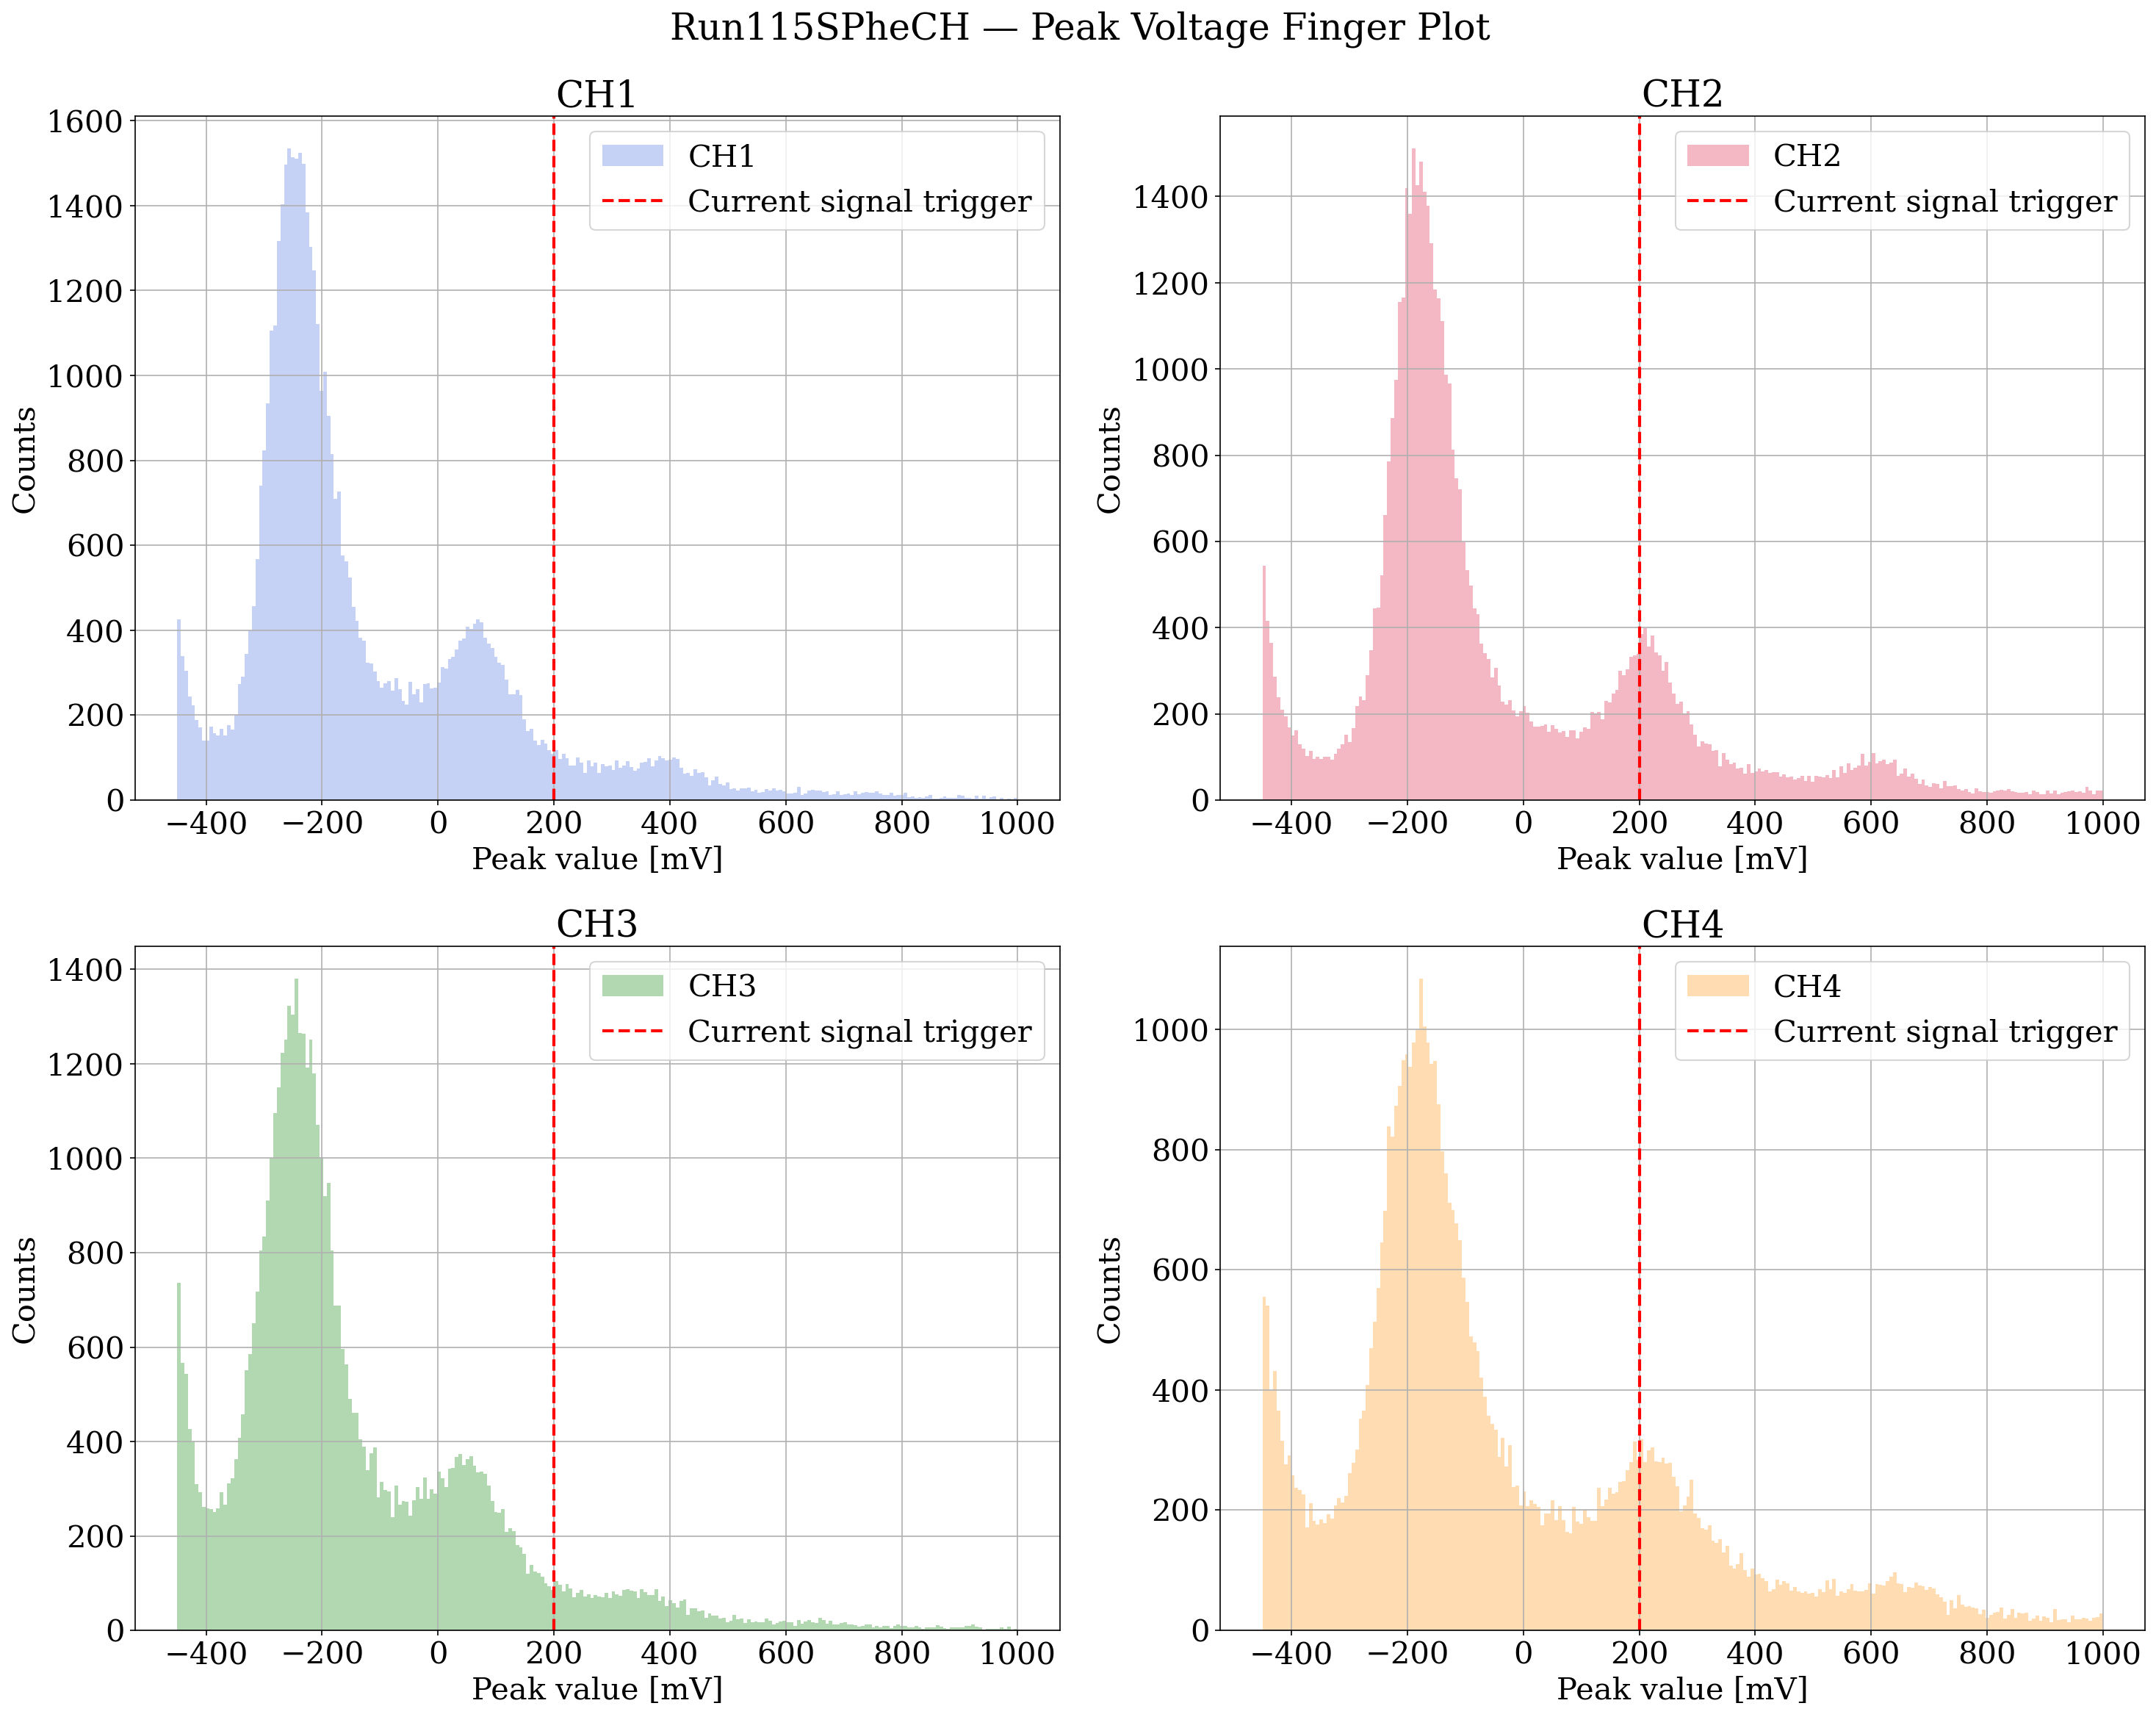

In [46]:
n_gaussians = 2
opt_A, opt_mu, opt_sigma, opt_mu_errors = FingerPlotVoltage(filtered_df, channels, n_gaussians)
